# Loan Default Prediction: EDA and ML Pipeline
This notebook demonstrates the end-to-end ML pipeline: data ingestion, preparation, balancing (SMOTE), modeling, and evaluation.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE


## 1. Data Ingestion
Load the raw dataset.

In [2]:
df = pd.read_csv("../data/raw/Loan_Default.csv")
print("Shape:", df.shape)
df.head()


Shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 2. Data Validation & EDA
Check for missing values and general dataset health.

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with Missing Values:")
print(missing)


Columns with Missing Values:
Upfront_charges              39642
Interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
property_value               15098
LTV                          15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
age                            200
submission_of_application      200
loan_purpose                   134
Neg_ammortization              121
term                            41
dtype: int64


## 3. Data Preparation
Drop unused columns, impute missing values, and encode categorical variables.

In [4]:
# Drop unnecessary columns
df = df.drop(columns=["ID", "Interest_rate_spread"], errors="ignore")
print("Shape after dropping columns:", df.shape)

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
if "Status" in numeric_cols:
    numeric_cols.remove("Status")

# Impute missing values
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# One-hot encoding for categorical variables
df = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df.shape)


Shape after dropping columns: (148670, 32)


Shape after encoding: (148670, 49)


## 4. Class Balancing with SMOTE
Balance the dataset, then export the clean & balanced data.

In [5]:
X = df.drop("Status", axis=1)
y = df["Status"]
print("Original Features shape:", X.shape)
print("Original Target shape:", y.shape)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("Resampled Features shape:", X_resampled.shape)
print("Resampled Target shape:", y_resampled.shape)

# Combine and export
df_smote = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name="Status")], axis=1)
os.makedirs("../data/processed", exist_ok=True)
output_path = "../data/processed/Loan_Default_smote_clean.csv"
df_smote.to_csv(output_path, index=False)
print(f"Balanced dataset saved to {output_path}")


Original Features shape: (148670, 48)
Original Target shape: (148670,)


Resampled Features shape: (224062, 48)
Resampled Target shape: (224062,)


Balanced dataset saved to ../data/processed/Loan_Default_smote_clean.csv


## 5. Model Training Pipeline
Train/test split, feature scaling, and training a baseline logistic regression.

In [6]:
# Split the resampled data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model training complete.")


Model training complete.


## 6. Model Evaluation
Evaluate model performance using Accuracy, Confusion Matrix, and ROC-AUC.

In [7]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8832035346885948

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89     22341
           1       0.94      0.82      0.88     22472

    accuracy                           0.88     44813
   macro avg       0.89      0.88      0.88     44813
weighted avg       0.89      0.88      0.88     44813



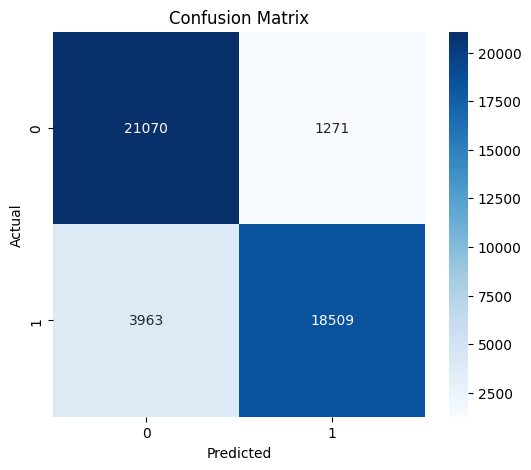

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


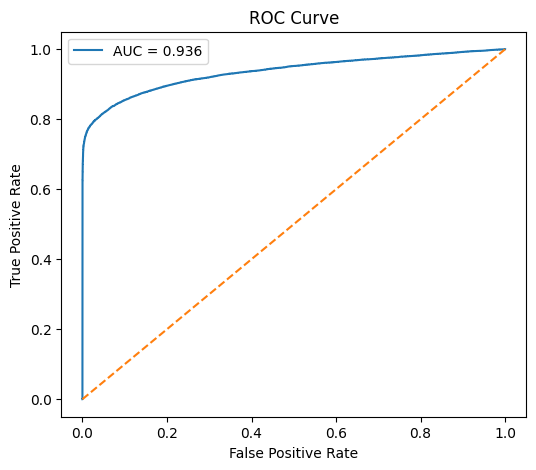

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = " + str(round(auc_score, 3)))
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 7. Model Export
Save the scaler, model, and feature columns for inference.

In [10]:
os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/logistic_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X.columns), "../models/feature_columns.pkl")
print("Model, scaler, and features saved successfully.")


Model, scaler, and features saved successfully.
